Deep learning projects have extremely specific dependency version requirements. PyTorch, ultralytics (YOLOv8),
and OpenCV all have tight interdependencies. If you install them into your base Python environment,
you will eventually break other projects or get broken by them. A separate conda env isolates everything.

In [1]:
import os
from pathlib import Path

# print current working directiory
print(f"Working Directory: {os.getcwd()}")

# verify that the dataset structure is visible from here
data_yaml = Path(r"C:\Users\user\Desktop\ML & DL projects\CV Real time Safety system\dataset\Construction Site Safety.v27-yolov8.yolov8\data.yaml")
print(r"data.yaml found: {data_yaml.exists()}")

train_imgs = Path(r"C:\Users\user\Desktop\ML & DL projects\CV Real time Safety system\dataset\Construction Site Safety.v27-yolov8.yolov8\train\images")
print("Train images found:", train_imgs.exists())
print("Train image count:", len(list(train_imgs.glob("*.jpg"))))
print()
test_imgs = Path(r"C:\Users\user\Desktop\ML & DL projects\CV Real time Safety system\dataset\Construction Site Safety.v27-yolov8.yolov8\test\images")
print("Test images found:", test_imgs.exists())
print("Test image count:", len(list(test_imgs.glob("*.jpg"))))
print()
valid_imgs = Path(r"C:\Users\user\Desktop\ML & DL projects\CV Real time Safety system\dataset\Construction Site Safety.v27-yolov8.yolov8\valid\images")
print("valid images found:", valid_imgs.exists())
print("valid image count:", len(list(valid_imgs.glob("*.jpg"))))

Working Directory: c:\Users\user\Desktop\ML & DL projects\CV Real time Safety system\notebooks
data.yaml found: {data_yaml.exists()}
Train images found: True
Train image count: 2588

Test images found: True
Test image count: 82

valid images found: True
valid image count: 113


In [2]:
# inspecting yaml
import yaml

with open(r"C:\Users\user\Desktop\ML & DL projects\CV Real time Safety system\dataset\Construction Site Safety.v27-yolov8.yolov8\data.yaml") as f:
    config = yaml.safe_load(f)

    print("Number of classes:", config['nc'])
    print("Class names:", config['names'])

Number of classes: 10
Class names: ['Hardhat', 'Mask', 'NO-Hardhat', 'NO-Mask', 'NO-Safety Vest', 'Person', 'Safety Cone', 'Safety Vest', 'machinery', 'vehicle']


In [3]:
for i, name in enumerate(config['names']):
    print(f'class{i}: {name}')

class0: Hardhat
class1: Mask
class2: NO-Hardhat
class3: NO-Mask
class4: NO-Safety Vest
class5: Person
class6: Safety Cone
class7: Safety Vest
class8: machinery
class9: vehicle


## **EDA**

Common problems caught only in EDA: severe class imbalance (1000 'Hardhat' images but 40 'NO-Hardhat'),
mislabelled images, images from only one lighting condition, annotation errors.
If you train on bad data without knowing it, your model will give wrong results and you won't know why.

In [4]:
# Count images and labels per split
dataset_path = Path(r'C:\Users\user\Desktop\ML & DL projects\CV Real time Safety system\dataset\Construction Site Safety.v27-yolov8.yolov8')
for split in ('train', 'valid', 'test'):
    imgs = list((dataset_path/split/'images').glob('*.jpg'))
    labels = list((dataset_path/split/'labels').glob('*.txt'))
    print(f'{split:8s}: {len(imgs):4d} images, {len(labels):4d} label files')

train   : 2588 images, 2588 label files
valid   :  113 images,  113 label files
test    :   82 images,   82 label files


### Class Balance Check

In [5]:
import yaml, collections, matplotlib.pyplot as plt

with open(dataset_path/'data.yaml') as f:
    cfg= yaml.safe_load(f)
class_names = cfg['names']

class_counts = collections.Counter()

for label_file in (dataset_path/'train'/'labels').glob('*.txt'):
    with open(label_file) as f:
        for line in f:
            if line.strip():
                class_id = int(line.split()[0])
                class_counts[class_id] +=1

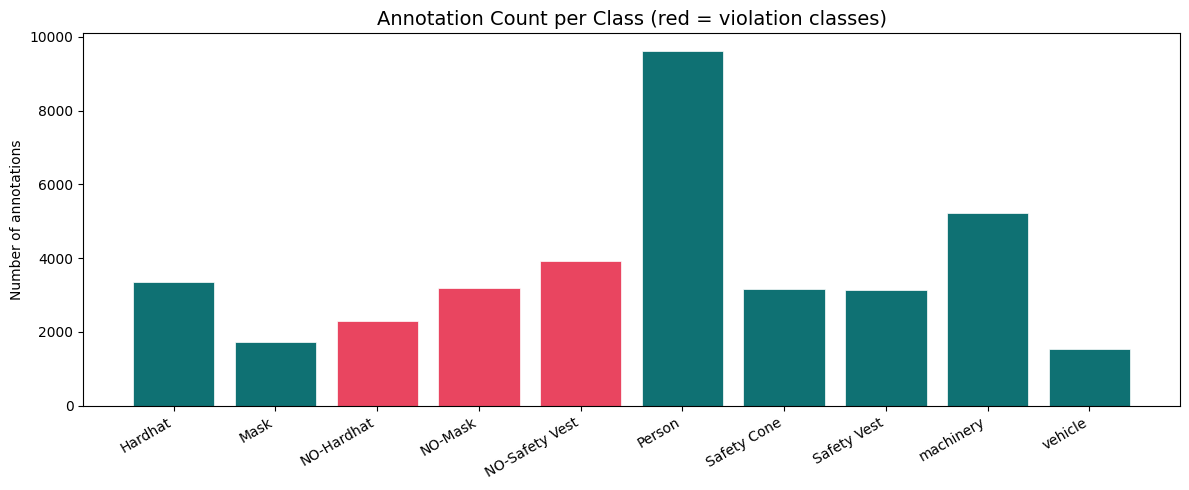


Class counts:
 Hardhat             : 3342-> percentage of total = 8.994752
 Mask                : 1729-> percentage of total = 4.653479
 NO-Hardhat          : 2289-> percentage of total = 6.160678
 NO-Mask             : 3187-> percentage of total = 8.577580
 NO-Safety Vest      : 3926-> percentage of total = 10.566546
 Person              : 9616-> percentage of total = 25.880770
 Safety Cone         : 3169-> percentage of total = 8.529135
 Safety Vest         : 3143-> percentage of total = 8.459158
 machinery           : 5223-> percentage of total = 14.057327
 vehicle             : 1531-> percentage of total = 4.120576


In [6]:
# Plot
fig, ax = plt.subplots(figsize=(12, 5))
classes = [class_names[i] for i in sorted(class_counts)]
counts = [class_counts[i] for i in sorted(class_counts)]
colors = ['#E94560' if 'NO-' in c else '#0F7173' for c in classes]
ax.bar(classes, counts, color=colors, edgecolor='white', linewidth=0.5)
ax.set_title('Annotation Count per Class (red = violation classes)', fontsize=14)
ax.set_ylabel('Number of annotations')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig('class_distribution.png', dpi=150)
plt.show()
print('\nClass counts:')
for name, count in zip(classes, counts):
    print(f' {name:20s}: {count:4d}-> percentage of total = {(count/(sum(counts)))*100:4f}')

### 1. Is the Imbalance Significant?

**Yes, the imbalance is moderately significant and highly structural**, but it is entirely typical for this type of safety monitoring dataset. 

Here is how we can break down the distribution to understand why it matters:

* **The "Person" Dominance (25.88%):** At over a quarter of the total dataset, the `Person` class is heavily over-represented. This happens structurally because almost every worker in an image will have a bounding box for `Person` wrapping around their entire body, alongside smaller bounding boxes for their safety gear. While the model will become excellent at locating humans, an overwhelming signal from one class can sometimes cause the model to misclassify specific equipment sub-regions.
* **The Compliance vs. Violation Imbalance:** Looking closely at the standard safety equipment classes versus their corresponding violation (`NO-`) classes:
    * `Hardhat` (8.99%) vs. `NO-Hardhat` (6.16%)
    * `Safety Vest` (8.45%) vs. `NO-Safety Vest` (10.56%)
    * `Mask` (4.65%) vs. `NO-Mask` (8.57%)
    
    Interestingly, for vests and masks, **there are actually more violation instances than compliant instances in this dataset.** While the inverse is usually true in real-world environments (where safety violations are rare), this is a positive factor for training. Because the violation categories hold healthy percentages of the dataset (~6% to 10.5%), the model has a strong amount of exposure to edge cases and violation examples.
* **The Rare Classes:** The absolute lowest minority classes are `vehicle` (4.12%) and `Mask` (4.65%). The model is most likely to struggle with precision and recall on these specific classes simply because it has fewer overall examples to learn from.

---

### Mitigation Strategy for Training (`NB-03`)

Since this is an object detection dataset where multiple classes overlap in a single image, standard classification oversampling won't work cleanly. Instead, we should mitigate this during the model training phase:

1. **Activate Focal Loss:** We can pass `fl_gamma=1.5` into `model.train()`. This down-weights the loss from easy-to-classify examples (like the abundant `Person` class) and forces the optimizer to focus heavily on correcting errors made on minority classes like `vehicle` or `Mask`.
2. **Monitor Per-Class Metrics:** After training, we must analyze the per-class `AP@50` printed by `model.val()`. If the rare classes show significantly lower precision/recall than the others, we can apply targeted data augmentations to those specific classes using Roboflow before jumping into deployment.

In [7]:
print(sum(counts))

37155


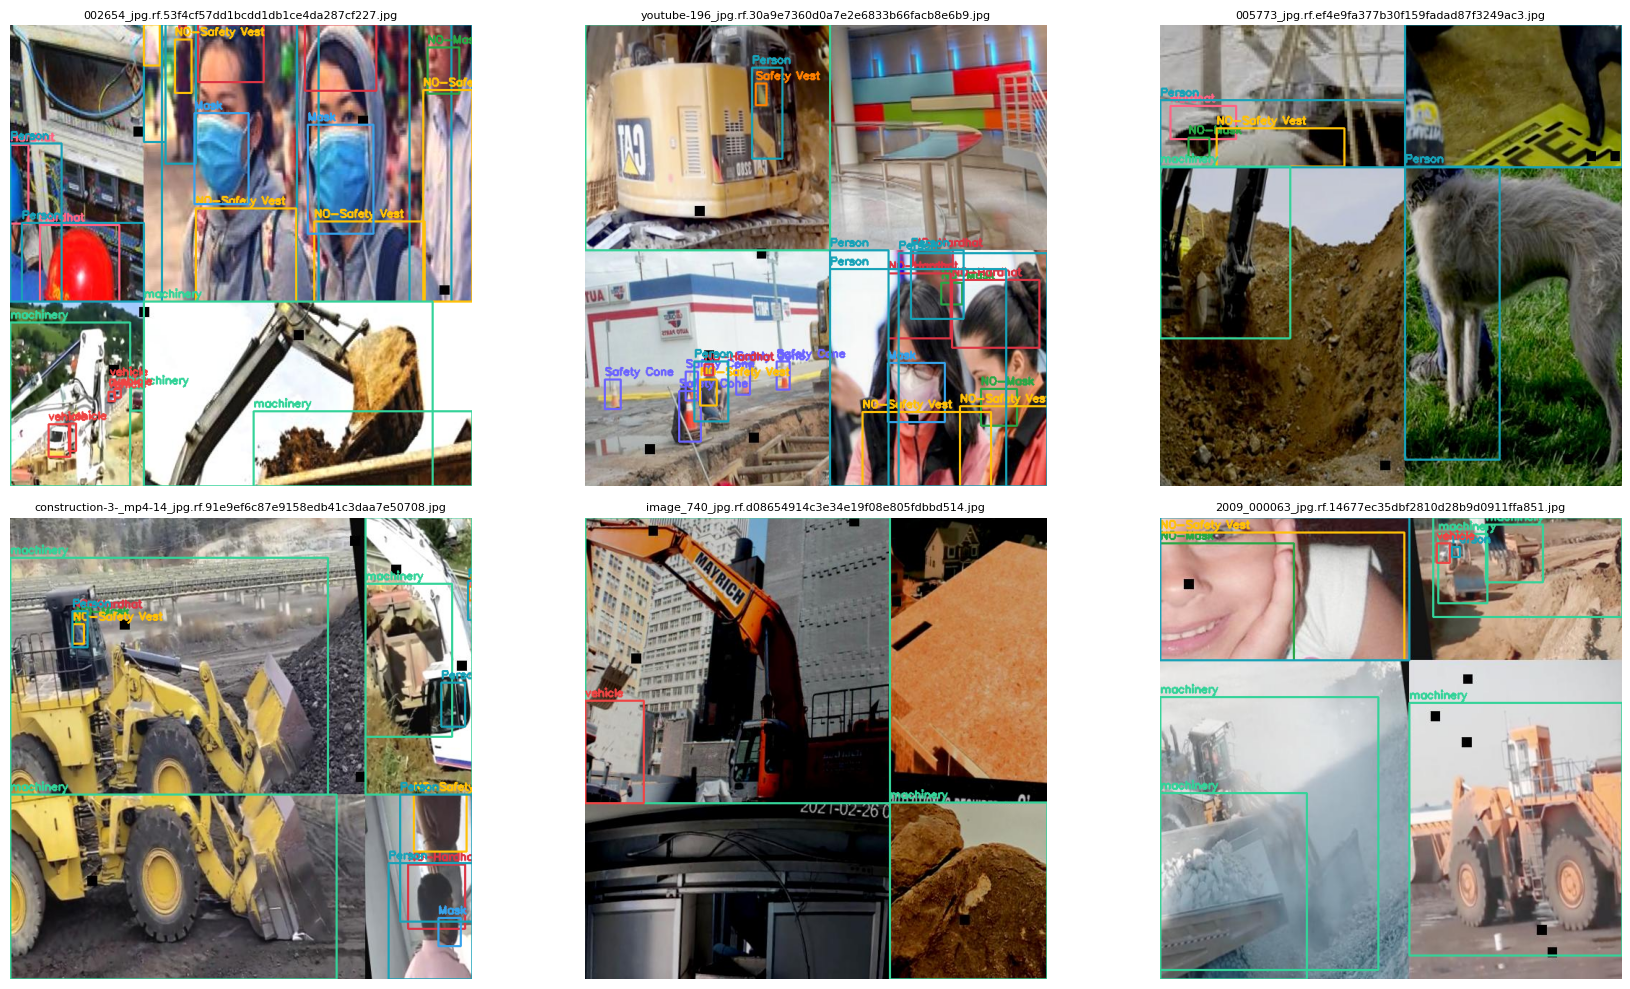

In [8]:
# visualize sample images with bounding boxes
import cv2, random, numpy as np

COLORS = [
(255, 99, 132), (54, 162, 235), (220, 53, 69), (40, 167, 69),
(255, 193, 7), (23, 162, 184), (108, 99, 255), (255, 128, 0),
(52, 211, 153), (239, 68, 68)
]

def draw_boxes(img_path):
    img = cv2.imread(str(img_path))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    h, w = img.shape[:2]
    lbl_path = str(img_path).replace('images','labels').replace('.jpg','.txt')
    if Path(lbl_path).exists():
        with open(lbl_path) as f:
            for line in f:
                parts = line.strip().split()
                if not parts: continue
                cls = int(parts[0])
                cx, cy, bw, bh = map(float, parts[1:])
                x1 = int((cx - bw/2) * w); y1 = int((cy - bh/2) * h)
                x2 = int((cx + bw/2) * w); y2 = int((cy + bh/2) * h)
                color = COLORS[cls % len(COLORS)]
                cv2.rectangle(img, (x1,y1), (x2,y2), color, 2)
                cv2.putText(img, class_names[cls], (x1, y1-6),
                cv2.FONT_HERSHEY_SIMPLEX, 0.5, color, 2)
    return img
imgs = list((dataset_path / 'train' / 'images').glob('*.jpg'))
sample = random.sample(imgs, 6)
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
for ax, p in zip(axes.flat, sample):
    ax.imshow(draw_boxes(p))
    ax.set_title(p.name, fontsize=8)
    ax.axis('off')
plt.tight_layout()
plt.savefig('sample_images.png', dpi=150)
plt.show()
